In [1]:
%matplotlib widget
import os
import joblib
from pathlib import Path
import torch, einops
import matplotlib.pyplot as plt
import numpy as np

from util import (
    configure_logging,
    download_and_concat,
    textfile_to_tokens_as_binary,
    get_batch,
    save_checkpoint,
    load_checkpoint
)
from tokenizer import train_bpe, Tokenizer
from transformer import (
    Embedding,
    TransformerBlock,
    RMSNorm,
    Linear,
    MultiHeadAttention,
    TransformerLM,
)
from optimizer import AdamW

configure_logging()  # or configure_logging(logging.DEBUG) for verbose

In [ ]:
# download some internet text
urls = [
    "https://gutenberg.org/cache/epub/1184/pg1184.txt",
    "https://gutenberg.org/cache/epub/1513/pg1513.txt",
]
# download_and_concat(urls, "data/combined.txt", separator="\n<|endoftext|>\n")


# convert the file into a raw-binary which we can read as mmmap.
# textfile_to_tokens_as_binary(
#     "data/TinyStoriesV2-GPT4-train.txt", "data/train.bin", tokenizer, "wb"
# )
# textfile_to_tokens_as_binary(
#     "data/TinyStoriesV2-GPT4-valid.txt", "data/valid.bin", tokenizer, "wb"
# )
# os.path.getsize("data/train.bin")
# data = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
# get_batch(data, 20, 5) returns 20 batches of length 5 sequences inputs,labels

15:03:54 util INFO [1/2] downloading https://gutenberg.org/cache/epub/1184/pg1184.txt
15:03:55 util INFO [2/2] downloading https://gutenberg.org/cache/epub/1513/pg1513.txt
15:03:56 util INFO wrote data/combined.txt (2,956,643 bytes)


In [2]:
# tokenize this text
special_tokens = ["<|endoftext|>", "<|begin|>", "<|end|>"]
path = "../data/TinyStoriesV2-GPT4-valid.txt"
vocabulary_size = 5000

tokenizer_dir = Path("tokenizer")
tokenizer_dir.mkdir(exist_ok=True)
tokenizer_path = tokenizer_dir / "tokenizer.joblib"

if tokenizer_path.exists():
    tokenizer = joblib.load(tokenizer_path)
else:
    vocab, merges = train_bpe(path, vocabulary_size, special_tokens)
    tokenizer = Tokenizer(vocab, merges, special_tokens)
    joblib.dump(tokenizer, tokenizer_path)

In [3]:
train_data = np.memmap("data/train.bin", dtype=np.uint16, mode="r")
valid_data = np.memmap("data/valid.bin", dtype=np.uint16, mode="r")

In [43]:
# initialize the model
context_length = 256
d_model = 128
d_ff = 1344
num_heads = 16
num_layers = 4
rope_theta = 10000
model = TransformerLM(
    vocabulary_size, context_length, num_layers, d_model, d_ff, num_heads, rope_theta
)
device = "mps"
model.to(device);

In [44]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters())

In [45]:
log = []

resuming from iteration 20


training: 100%|██████████| 120/120 [02:06<00:00,  1.05s/it, loss=3.6377]


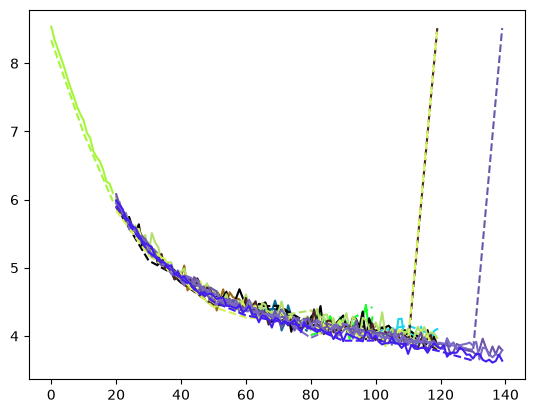

In [64]:
%matplotlib inline
from tqdm import tqdm
from IPython.display import display
import random

batch_size = 64
iterations = 120
val_every = 10  # how often to compute validation loss
save_every = 10  # how often to checkpoint
save_checkpoint_path = Path("checkpoints/latest.obj")
# resume from a checkpoint if one exists
load_checkpoint_path = Path("checkpoints/first.obj")

if load_checkpoint_path.exists():
    start_iteration = load_checkpoint(load_checkpoint_path, model, optimizer) + 1
    print(f"resuming from iteration {start_iteration}")
else:
    start_iteration = 0
    print("no checkpoint found, starting fresh")

run_iterations, run_losses = [], []
run_val_steps, run_val_losses = [], []

iteration_range = range(start_iteration, start_iteration + iterations)
pbar = tqdm(iteration_range, desc="training", colour="white")
try:
    for iteration in pbar:
        model.train()
        inputs, targets = get_batch(train_data, batch_size, context_length, device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs.transpose(1, 2), targets)
        loss.backward()
        optimizer.step()

        run_iterations.append(iteration)
        run_losses.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

        if iteration % val_every == 0:
            model.eval()
            with torch.no_grad():
                vi, vt = get_batch(valid_data, batch_size, context_length, device)
                vloss = loss_function(model(vi).transpose(1, 2), vt)
            run_val_steps.append(iteration)
            run_val_losses.append(vloss.item())

        if iteration % save_every == 0:
            save_checkpoint(model, optimizer, iteration, save_checkpoint_path)
finally:
    save_checkpoint(model, optimizer, iteration, save_checkpoint_path)

log.append({
    "iterations": run_iterations,
    "losses": run_losses,
    "val_steps": run_val_steps,
    "val_losses": run_val_losses,
    "color": f"#{random.randint(0, 0xFFFFFF):06x}",
})

# same color for train/val within a run so runs are told apart by color alone
for run in log:
    plt.plot(run["iterations"], run["losses"], color=run["color"], linestyle="-")
    plt.plot(run["val_steps"], run["val_losses"], color=run["color"], linestyle="--")

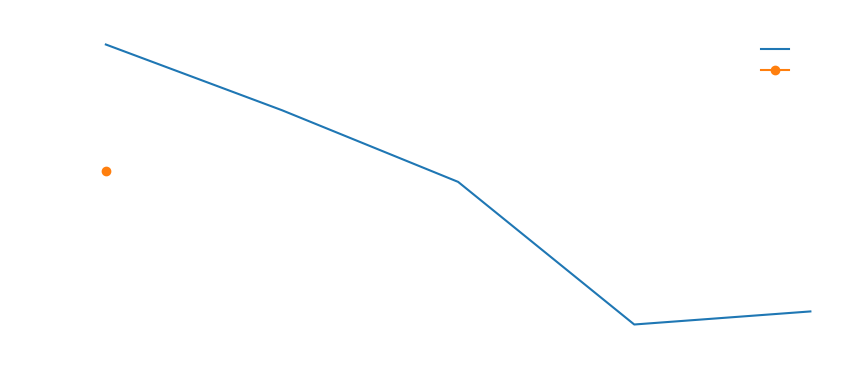

training:  50%|█████     | 5/10 [00:07<00:07,  1.45s/it, loss=5.7468]


KeyboardInterrupt: 

In [63]:
%matplotlib inline
from tqdm import tqdm
from util import LiveLossPlot

batch_size = 64
iterations = 10
val_every = 20  # how often to compute validation loss
save_every = 50  # how often to checkpoint


with LiveLossPlot(every=5) as plot:
    iteration_range = range(start_iteration, start_iteration + iterations)
    pbar = tqdm(iteration_range, desc="training", colour="white")
    for iteration in pbar:
        model.train()
        inputs, targets = get_batch(train_data, batch_size, context_length, device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs.transpose(1, 2), targets)
        loss.backward()
        optimizer.step()

        plot.log(loss.item(), iteration)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

        if iteration % val_every == 0:
            model.eval()
            with torch.no_grad():
                vi, vt = get_batch(valid_data, batch_size, context_length, device)
                vloss = loss_function(model(vi).transpose(1, 2), vt)
            plot.log_val(vloss.item(), iteration)

        if iteration % save_every == 0:
            save_checkpoint(model, optimizer, iteration, checkpoint_path)
    save_checkpoint(model, optimizer, iteration, checkpoint_path)

In [ ]:
run_iterations


In [ ]:
import sys


def generate(
    prompt: str, max_tokens: int = 400, temperature: float = 0.9, width: int = 90
) -> str:
    """Stream-decode tokens from `model` and print with word-wrap at `width`.

    Uses the surrounding notebook scope for `model`, `tokenizer`, `context_length`,
    and `device`. Stops early when the <|endoftext|> token is sampled. Returns the
    full generated string (prompt + completion) for any post-hoc use.
    """
    EOT_ID = tokenizer.encode("<|endoftext|>")[0]

    all_ids = tokenizer.encode(prompt)
    model_input = torch.tensor(all_ids, dtype=torch.long).unsqueeze(0).to(device)

    col = 0
    word_buf = ""

    def stream(text: str) -> None:
        nonlocal col, word_buf
        text = text.replace("\n", " ")
        for ch in text:
            if ch == " ":
                if word_buf:
                    space = 1 if col > 0 else 0
                    if col + space + len(word_buf) > width:
                        sys.stdout.write("\n")
                        col = 0
                    elif space:
                        sys.stdout.write(" ")
                        col += 1
                    sys.stdout.write(word_buf)
                    col += len(word_buf)
                    word_buf = ""
            else:
                word_buf += ch
        sys.stdout.flush()

    stream(prompt)
    printed = prompt

    model.eval()
    with torch.no_grad():
        for _ in range(max_tokens):
            logits = model(model_input)[:, -1]
            probs = torch.softmax(logits / temperature, dim=-1)
            pred = torch.multinomial(probs, num_samples=1)
            token_id = pred.item()
            if token_id == EOT_ID:
                break
            all_ids.append(token_id)
            model_input = torch.cat([model_input, pred], dim=1)[:, -context_length:]

            decoded = tokenizer.decode(all_ids)
            new_part = decoded[len(printed) :]
            if new_part:
                stream(new_part)
                printed = decoded

    stream(" ")  # flush trailing partial word
    return tokenizer.decode(all_ids)

In [ ]:
generate("tell me a story about", max_tokens=400, temperature=0.9);